# Ноутбук по случайному лесу


# 1. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Инструменты для предобработки и моделирования
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Модели
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Загрузка и первичный осмотр

In [6]:
data = pd.read_csv('ToyotaCorolla.csv')

print("Первые 3 строк датасета:")
print(data.head(3))


Первые 3 строк датасета:
   Id                                          Model  Price  Age_08_04  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color  ... Powered_Windows  \
0         10      2002  46986    Diesel  90          1  ...               1   
1         10      2002  72937    Diesel  90          1  ...               0   
2          9      2002  41711    Diesel  90          1  ...               0   

   Power_Steering  Radio  Mistlamps  Sport_Model  Backseat_Divider  \
0               1      0          0            0                 1   
1               1      0          0            0                 1   
2               1      0          0            0                 1   

   Metallic_Rim  Radio_cassette  Parking_Assistant  Tow_Bar  
0             0   

In [7]:
print("\nИнформация о датасете:")
data.info()
print("\nСтатистика по целевой переменной (Price):")
print(data['Price'].describe())


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax     

In [9]:
rows, cols = data.shape
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns
date_cols = data.select_dtypes(include=['datetime64']).columns

num_count = len(num_cols)
cat_count = len(cat_cols)
date_count = len(date_cols)

missing_cols_count = data.isnull().any().sum()
missing_total = data.isnull().sum().sum()
missing_pct = (missing_total / (rows * cols)) * 100

print(f"Размер датасета: {rows} строк, {cols} столбцов")
print(f"Типы признаков: Числовые {num_count}, Категориальные {cat_count}, Дата/время {date_count}")
print(f"Наличие пропусков: {missing_cols_count} колонок с пропусками, всего {missing_total} пропусков ({missing_pct:.1f}%)")


Размер датасета: 1436 строк, 39 столбцов
Типы признаков: Числовые 36, Категориальные 3, Дата/время 0
Наличие пропусков: 0 колонок с пропусками, всего 0 пропусков (0.0%)


# 3. EDA

In [10]:
import re

data_clean = data.copy()

# Извлекаем признаки из названия модели
def extract_car_features(model_name):
    """Извлекает характеристики из названия модели"""
    
    # Объем двигателя
    engine_match = re.search(r'(\d\.\d)', model_name)
    engine_volume = float(engine_match.group(1)) if engine_match else None
    
    # Клапаны
    valves_match = re.search(r'(\d+)V', str(model_name))
    valves = int(valves_match.group(1)) if valves_match else None  
      
    # Тип кузова
    if 'HATCHB' in model_name:
        body_type = 'Hatchback'
    elif 'SEDAN' in model_name:
        body_type = 'Sedan'
    elif 'WAGON' in model_name:
        body_type = 'Wagon'
    elif 'LIFTB' in model_name:
        body_type = 'Liftback'
    else:
        body_type = 'Other'
    
    # Комплектация
    if 'LINEA TERRA' in model_name:
        trim = 'Terra'
    elif 'LINEA LUNA' in model_name:
        trim = 'Luna'
    elif 'SOL' in model_name:
        trim = 'Sol'
    else:
        trim = 'Other'
    
    # Количество дверей
    if '2/3-Doors' in model_name:
        doors = '2-3'
    elif '4/5-Doors' in model_name:
        doors = '4-5'
    else:
        doors = 'Other'
    
    # Тип топлива (если есть)
    if 'VVT I' in model_name:
        fuel_type = 'VVT-i'
    else:
        fuel_type = 'Standard'
    
    return pd.Series({
        'engine_volume': engine_volume,
        'valves': valves,
        'body_type': body_type,
        'trim': trim,
        'doors': doors,
        'fuel_type': fuel_type
    })

# Применяем извлечение признаков
features_data = data_clean['Model'].apply(extract_car_features)
data_clean = pd.concat([data_clean, features_data], axis=1)

df_clean = data_clean.drop('Model', axis=1)

print("Извлеченные признаки:")
print(data_clean[['engine_volume', 'valves', 'body_type', 'trim', 'doors', 'fuel_type']].head(10))
print(f"\nРазмер датасета после извлечения признаков из модели: {data_clean.shape}")

Извлеченные признаки:
   engine_volume  valves  body_type   trim doors fuel_type
0            2.0     NaN  Hatchback  Other   2-3  Standard
1            2.0     NaN  Hatchback  Other   2-3  Standard
2            2.0     NaN  Hatchback  Other   2-3  Standard
3            2.0     NaN  Hatchback  Other   2-3  Standard
4            2.0     NaN  Hatchback    Sol   2-3  Standard
5            2.0     NaN  Hatchback    Sol   2-3  Standard
6            2.0     NaN      Other  Other   2-3  Standard
7            2.0     NaN      Other  Other   2-3  Standard
8            NaN     NaN      Other  Other   2-3     VVT-i
9            1.9     NaN  Hatchback  Other   2-3  Standard

Размер датасета после извлечения признаков из модели: (1436, 45)


In [14]:
missing_engine = data_clean[data_clean['engine_volume'].isna()]
print(f"Процент пропусков объема двигателя: {len(missing_engine)/len(data_clean)*100:.2f}%")

# Можно удалить эти объекты
data_clean = data_clean.dropna(subset=['engine_volume'])
print(f"Размер датасета после удаления: {data_clean.shape}")


# Заполняем пропуски модой внутри каждой группы engine_volume
def infer_valves_by_group(row):
    if pd.notna(row['valves']):
        return row['valves']
    
    # Получаем моду для данной группы engine_volume
    group_mode = data_clean.groupby('engine_volume')['valves'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)
    
    # Если для этого объема есть мода, используем её
    if row['engine_volume'] in group_mode.index and pd.notna(group_mode[row['engine_volume']]):
        return group_mode[row['engine_volume']]
    else:
        # Если нет, используем общую моду
        return data_clean['valves'].mode()[0]

data_clean['valves'] = data_clean.apply(infer_valves_by_group, axis=1)

print(f"Пропусков по колонке valves после заполнения: {data_clean['valves'].isnull().sum()}")
print(f'Пропусков в чистом датасете: {data_clean.isnull().sum().sum()}')

Процент пропусков объема двигателя: 0.00%
Размер датасета после удаления: (1428, 45)
Пропусков по колонке valves после заполнения: 0
Пропусков в чистом датасете: 0


In [15]:
# One-Hot Encoding для Fuel_Type с drop_first=True (избегаем мультиколлинеарности)
# Создаем новые столбцы и добавляем их к датасету
data_clean = pd.get_dummies(data_clean, columns=['Fuel_Type'], prefix='fuel', drop_first=True)

# Проверка: новые столбцы добавлены
print("Новые столбцы:", [col for col in data_clean.columns if col.startswith('fuel_')])
print("Размер датасета:", data_clean.shape)

# Если нужно удалить исходный столбец Fuel_Type (get_dummies уже удалил его автоматически)
# Исходный столбец 'Fuel_Type' был удален, вместо него созданы fuel_Petrol, fuel_Diesel

Новые столбцы: ['fuel_type', 'fuel_Diesel', 'fuel_Petrol']
Размер датасета: (1428, 46)


In [ ]:
# One-Hot Encoding для Color
data_clean = pd.get_dummies(data_clean, columns=['Color'], prefix='color', drop_first=True)

# Проверка
color_cols = [col for col in data_clean.columns if col.startswith('color_')]
print(f"Создано {len(color_cols)} новых столбцов")
print("Новые столбцы:", color_cols[:5])
print("Размер датасета:", data_clean.shape)


Создано 9 новых столбцов
Новые столбцы: ['color_Black', 'color_Blue', 'color_Green', 'color_Grey', 'color_Red']
Размер датасета: (1428, 54)


In [18]:
# Создание новых признаков на основе Mfg_Month и Mfg_Year
print("=== Создание признаков на основе даты производства ===\n")

# Текущий год (максимальный год в данных)
current_year = data_clean['Mfg_Year'].max()
print(f"Максимальный год производства: {current_year}")

# Создаем сезон производства (на основе месяца)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

data_clean['Season'] = data_clean['Mfg_Month'].apply(get_season)

# Создаем признак "квартал производства"
data_clean['Quarter'] = pd.cut(data_clean['Mfg_Month'], 
                                bins=[0, 3, 6, 9, 12], 
                                labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Создаем признак "год выпуска" (как категорию)
data_clean['Mfg_Year_Cat'] = data_clean['Mfg_Year'].astype(str)

print("Созданы новые признаки:")
print(f"- Season (сезон производства): {data_clean['Season'].unique()}")
print(f"- Quarter (квартал): {data_clean['Quarter'].unique()}")
print(f"- Mfg_Year_Cat (год как категория): {data_clean['Mfg_Year_Cat'].unique()}")
print(f'Размер датасета: {data_clean.shape}')

=== Создание признаков на основе даты производства ===

Максимальный год производства: 2004
Созданы новые признаки:
- Season (сезон производства): ['Autumn' 'Summer' 'Spring' 'Winter']
- Quarter (квартал): ['Q4', 'Q3', 'Q1', 'Q2']
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']
- Mfg_Year_Cat (год как категория): ['2002' '2003' '2004' '2001' '2000' '1999' '1998']
Размер датасета: (1428, 57)


# 4. Определение признаков и целевой переменной

In [32]:
target = 'Price'

# Числовые признаки
numeric_features = [
    'Age_08_04', 'KM', 'HP', 'CC', 'Doors', 'Cylinders', 
    'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period',
    'engine_volume', 'valves', 'Mfg_Year'
]

# Категориальные признаки
categorical_features = ['body_type', 'trim', 'doors', 'fuel_type', 'Season', 'Quarter', 'Mfg_Year_Cat']

# Бинарные признаки (0/1)
binary_features = [
    'Met_Color', 'Automatic', 'Mfr_Guarantee', 'BOVAG_Guarantee',
    'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco',
    'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows',
    'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model',
    'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette',
    'Parking_Assistant', 'Tow_Bar'
]

# One-hot признаки
onehot_features = [col for col in data_clean.columns if col.startswith('color_')] + ['fuel_Diesel', 'fuel_Petrol']

all_feature_cols = numeric_features + categorical_features + binary_features + onehot_features
print(f"Всего признаков: {len(all_feature_cols)}")


Всего признаков: 53


# 5. Обучающая и тестовая выборки

In [33]:
X = data_clean[all_feature_cols]
y = data_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (1142, 53)
Тестовая выборка: (286, 53)


# 6. Пайплайн для обработки данных

In [34]:
# Для деревьев масштабирование не нужно, но One-Hot для категориальных признаков делаем.
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features), # Пропускаем числовые как есть
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), categorical_features),
        ('binary', 'passthrough', binary_features),
        ('onehot', 'passthrough', onehot_features)
    ])

# Для сравнения возьмем пайплайн с масштабированием из линейной регрессии
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), categorical_features),
        ('binary', 'passthrough', binary_features),
        ('onehot', 'passthrough', onehot_features)
    ])

# 7. Применение препроцессоров

In [35]:
# Для деревьев
X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree = preprocessor_tree.transform(X_test)

# Для линейных моделей (для честного сравнения позже)
X_train_lin = preprocessor_linear.fit_transform(X_train)
X_test_lin = preprocessor_linear.transform(X_test)

print(f"Размер данных для деревьев (train): {X_train_tree.shape}")
print(f"Размер данных для линейных моделей (train): {X_train_lin.shape}")

Размер данных для деревьев (train): (1142, 68)
Размер данных для линейных моделей (train): (1142, 68)


# 8. Обучение бейзлайна (DummyRegressor)


In [36]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_tree, y_train)
y_pred_dummy = dummy.predict(X_test_tree)

print("=== Бейзлайн (среднее значение) ===")
print(f"R2 на тесте: {r2_score(y_test, y_pred_dummy):.4f}")
print(f"RMSE на тесте: {np.sqrt(mean_squared_error(y_test, y_pred_dummy)):.2f}")

=== Бейзлайн (среднее значение) ===
R2 на тесте: -0.0048
RMSE на тесте: 3449.38


# 9. Обучение одиночного дерева решений (Decision Tree)

## Без ограничения глубины

In [38]:
# Обучим одно дерево. Для начала без ограничения глубины, чтобы посмотреть на переобучение
start_time_dt = time.time()
dt_full = DecisionTreeRegressor(random_state=42)
dt_full.fit(X_train_tree, y_train)
time_dt_full = time.time() - start_time_dt

y_pred_dt_full_train = dt_full.predict(X_train_tree)
y_pred_dt_full_test = dt_full.predict(X_test_tree)

print("\tОдиночное дерево (без ограничения глубины)")
print(f"Время обучения: {time_dt_full:.4f} сек")
print(f"Train R2: {r2_score(y_train, y_pred_dt_full_train):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_dt_full_test):.4f}")
print(f"Глубина дерева: {dt_full.get_depth()}")

	Одиночное дерево (без ограничения глубины)
Время обучения: 0.0481 сек
Train R2: 1.0000
Test R2: 0.8373
Глубина дерева: 22


## С ограничением глубины

In [ ]:
max_depth_rf = 10

start_time_dt_pruned = time.time()
dt_pruned = DecisionTreeRegressor(max_depth=max_depth_rf, random_state=42)
dt_pruned.fit(X_train_tree, y_train)
time_dt_pruned = time.time() - start_time_dt_pruned

y_pred_dt_pruned_train = dt_pruned.predict(X_train_tree)
y_pred_dt_pruned_test = dt_pruned.predict(X_test_tree)

print(f"\tОдиночное дерево (max_depth={max_depth_rf})")
print(f"Время обучения: {time_dt_pruned:.4f} сек")
print(f"Train R2: {r2_score(y_train, y_pred_dt_pruned_train):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_dt_pruned_test):.4f}")

	Одиночное дерево (max_depth=10)
Время обучения: 0.0183 сек
Train R2: 0.9800
Test R2: 0.8642


## Подбор гиперпараметров

In [60]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 12, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Запуск GridSearchCV для Decision Tree")
start_time_dt_gs = time.time()

dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
dt_gs.fit(X_train_tree, y_train)

time_dt_gs = time.time() - start_time_dt_gs

print(f"\tРезультаты GridSearch для Decision Tree")
print(f"Время подбора: {time_dt_gs:.2f} сек")
print(f"Лучшие параметры: {dt_gs.best_params_}")
print(f"Лучший CV R2: {dt_gs.best_score_:.4f}")

y_pred_dt_best = dt_gs.predict(X_test_tree)
print(f"Test R2: {r2_score(y_test, y_pred_dt_best):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt_best)):.2f}")

Запуск GridSearchCV для Decision Tree
Fitting 5 folds for each of 63 candidates, totalling 315 fits
	Результаты GridSearch для Decision Tree
Время подбора: 0.97 сек
Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучший CV R2: 0.8854
Test R2: 0.8826
Test RMSE: 1179.15


# 10. Обучение случайного леса (Random Forest)

## С базовыми параметрами

In [59]:
start_time_rf = time.time()
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=dt_gs.best_params_['max_depth'],  # используем лучшую глубину из дерева для сравнения
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_tree, y_train)
time_rf = time.time() - start_time_rf

y_pred_rf_train = rf.predict(X_train_tree)
y_pred_rf_test = rf.predict(X_test_tree)

print(f"\tСлучайный лес (n_estimators=100)")
print(f"Время обучения: {time_rf:.4f} сек")
print(f"Train R2: {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_rf_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_test)):.2f}")

	Случайный лес (n_estimators=100)
Время обучения: 0.3851 сек
Train R2: 0.9586
Test R2: 0.9131
Test RMSE: 1014.57


## Подбор гиперпараметров для Random Forest через GridSearchCV

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Запуск GridSearchCV для Random Forest")
start_time_rf_gs = time.time()

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_gs.fit(X_train_tree, y_train)

time_rf_gs = time.time() - start_time_rf_gs

print(f"\tРезультаты GridSearch для Random Forest")
print(f"Время подбора: {time_rf_gs:.2f} сек")
print(f"Лучшие параметры: {rf_gs.best_params_}")
print(f"Лучший CV R2: {rf_gs.best_score_:.4f}")

y_pred_rf_best = rf_gs.predict(X_test_tree)
print(f"Test R2: {r2_score(y_test, y_pred_rf_best):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_best)):.2f}")

Запуск GridSearchCV для Random Forest
	Результаты GridSearch для Random Forest
Время подбора: 32.19 сек
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Лучший CV R2: 0.9160
Test R2: 0.9157
Test RMSE: 999.07


# 11. Обучение линейных моделей для сравнения

In [ ]:
results_linear = {}

# 1. Ridge регрессия
print("1. Ridge регрессия...")
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

start_time = time.time()
ridge_gs = GridSearchCV(
    Ridge(random_state=42),
    param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
ridge_gs.fit(X_train_lin, y_train)
time_ridge = time.time() - start_time

results_linear['Ridge'] = {
    'model': ridge_gs.best_estimator_,
    'best_params': ridge_gs.best_params_,
    'best_cv_score': ridge_gs.best_score_,
    'pred_train': ridge_gs.predict(X_train_lin),
    'pred_test': ridge_gs.predict(X_test_lin),
    'time': time_ridge
}

print(f"   Лучший alpha: {ridge_gs.best_params_['alpha']}")
print(f"   Лучший CV R²: {ridge_gs.best_score_:.4f}")
print(f"   Время подбора: {time_ridge:.2f} сек\n")

# 2. Lasso регрессия
print("2. Lasso регрессия...")
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

start_time = time.time()
lasso_gs = GridSearchCV(
    Lasso(max_iter=10000, random_state=42),
    param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
lasso_gs.fit(X_train_lin, y_train)
time_lasso = time.time() - start_time

results_linear['Lasso'] = {
    'model': lasso_gs.best_estimator_,
    'best_params': lasso_gs.best_params_,
    'best_cv_score': lasso_gs.best_score_,
    'pred_train': lasso_gs.predict(X_train_lin),
    'pred_test': lasso_gs.predict(X_test_lin),
    'time': time_lasso
}

print(f"   Лучший alpha: {lasso_gs.best_params_['alpha']}")
print(f"   Лучший CV R²: {lasso_gs.best_score_:.4f}")
print(f"   Время подбора: {time_lasso:.2f} сек\n")

# 3. ElasticNet регрессия
print("3. ElasticNet регрессия...")
param_grid_en = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

start_time = time.time()
en_gs = GridSearchCV(
    ElasticNet(max_iter=10000, random_state=42),
    param_grid_en,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
en_gs.fit(X_train_lin, y_train)
time_en = time.time() - start_time

results_linear['ElasticNet'] = {
    'model': en_gs.best_estimator_,
    'best_params': en_gs.best_params_,
    'best_cv_score': en_gs.best_score_,
    'pred_train': en_gs.predict(X_train_lin),
    'pred_test': en_gs.predict(X_test_lin),
    'time': time_en
}

print(f"   Лучший alpha: {en_gs.best_params_['alpha']}")
print(f"   Лучший l1_ratio: {en_gs.best_params_['l1_ratio']}")
print(f"   Лучший CV R²: {en_gs.best_score_:.4f}")
print(f"   Время подбора: {time_en:.2f} сек\n")

print("=== Сводка по линейным моделям ===")
print(f"{'Модель':<12} {'Best Params':<35} {'CV R²':<8} {'Test R²':<8} {'Время (сек)':<10}")
print("-" * 70)
for name, res in results_linear.items():
    test_r2 = r2_score(y_test, res['pred_test'])
    print(f"{name:<12} {str(res['best_params']):<35} {res['best_cv_score']:.4f}   {test_r2:.4f}   {res['time']:.2f}")

1. Ridge регрессия...
   Лучший alpha: 0.1
   Лучший CV R²: 0.9054
   Время подбора: 0.17 сек

2. Lasso регрессия...
   Лучший alpha: 1.0
   Лучший CV R²: 0.9059
   Время подбора: 1.50 сек

3. ElasticNet регрессия...
   Лучший alpha: 0.001
   Лучший l1_ratio: 0.9
   Лучший CV R²: 0.9054
   Время подбора: 1.40 сек

=== Сводка по линейным моделям ===
Модель       Best Params                         CV R²    Test R²  Время (сек)
----------------------------------------------------------------------
Ridge        {'alpha': 0.1}                      0.9054   0.9131   0.17
Lasso        {'alpha': 1.0}                      0.9059   0.9147   1.50
ElasticNet   {'alpha': 0.001, 'l1_ratio': 0.9}   0.9054   0.9131   1.40


# 12. Сбор всех результатов в таблицу

In [55]:
results_df = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2', 'Test RMSE', 'Test MAE', 'Train Time (s)'])

def add_result(name, y_train_true, y_train_pred, y_test_true, y_test_pred, train_time=0):
    global results_df
    new_row = pd.DataFrame([{
        'Model': name,
        'Train R2': r2_score(y_train_true, y_train_pred),
        'Test R2': r2_score(y_test_true, y_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        'Test MAE': mean_absolute_error(y_test_true, y_test_pred),
        'Train Time (s)': train_time
    }])
    results_df = pd.concat([results_df, new_row], ignore_index=True)

# Добавляем бейзлайн
add_result('Dummy (Mean)', y_train, dummy.predict(X_train_tree), y_test, y_pred_dummy, 0)

# Добавляем деревья
add_result('Decision Tree (best)', 
           y_train, dt_gs.predict(X_train_tree), 
           y_test, y_pred_dt_best, 
           time_dt_gs)

add_result('Random Forest (base)', 
           y_train, y_pred_rf_train, 
           y_test, y_pred_rf_test, 
           time_rf)

add_result('Random Forest (best)', 
           y_train, rf_gs.predict(X_train_tree), 
           y_test, y_pred_rf_best, 
           time_rf_gs)

# Добавляем линейные модели с временем подбора
for name, res in results_linear.items():
    add_result(name, 
               y_train, res['pred_train'], 
               y_test, res['pred_test'], 
               res['time'])

print("=== СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===")
print(results_df.round(4).to_string(index=False))

# Определяем лучшую модель
best_model = results_df.loc[results_df['Test R2'].idxmax()]
print(f"\n=== ЛУЧШАЯ МОДЕЛЬ ===")
print(f"Модель: {best_model['Model']}")
print(f"Test R²: {best_model['Test R2']:.4f}")
print(f"Test RMSE: {best_model['Test RMSE']:.2f} евро")
print(f"Test MAE: {best_model['Test MAE']:.2f} евро")

=== СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===
               Model  Train R2  Test R2  Test RMSE  Test MAE Train Time (s)
        Dummy (Mean)    0.0000  -0.0048  3449.3757 2555.4303              0
Decision Tree (best)    0.9396   0.8826  1179.1526  910.2878       7.241826
Random Forest (base)    0.9586   0.9131  1014.5721  805.5419       0.260793
Random Forest (best)    0.9787   0.9157   999.0700  792.0068      32.416255
               Ridge    0.9274   0.9131  1014.6476  778.2896       0.166624
               Lasso    0.9272   0.9147  1005.1683  768.0861       1.496149
          ElasticNet    0.9274   0.9131  1014.4730  778.0929       1.402351

=== ЛУЧШАЯ МОДЕЛЬ ===
Модель: Random Forest (best)
Test R²: 0.9157
Test RMSE: 999.07 евро
Test MAE: 792.01 евро


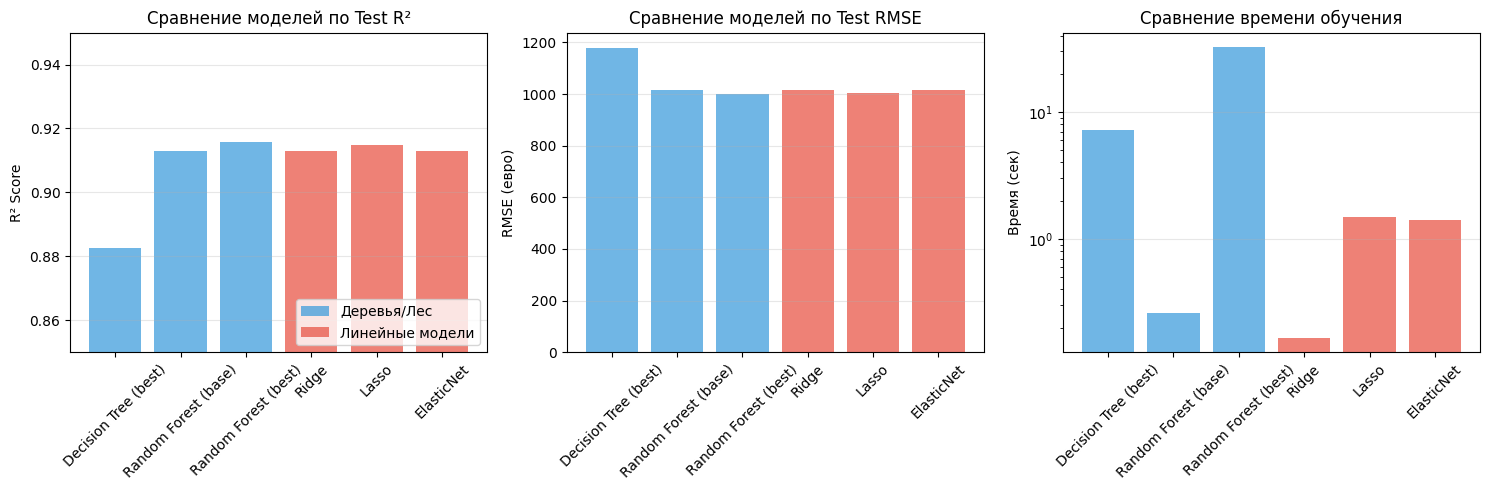

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Фильтруем бейзлайн для наглядности
models_to_plot = results_df[~results_df['Model'].str.contains('Dummy')]

# График R2
axes[0].bar(models_to_plot['Model'], models_to_plot['Test R2'], 
            color=['#3498db' if 'Tree' in m or 'Forest' in m else '#e74c3c' for m in models_to_plot['Model']], 
            alpha=0.7)
axes[0].set_title('Сравнение моделей по Test R²', fontsize=12)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0.85, 0.95)

# График RMSE
axes[1].bar(models_to_plot['Model'], models_to_plot['Test RMSE'], 
            color=['#3498db' if 'Tree' in m or 'Forest' in m else '#e74c3c' for m in models_to_plot['Model']], 
            alpha=0.7)
axes[1].set_title('Сравнение моделей по Test RMSE', fontsize=12)
axes[1].set_ylabel('RMSE (евро)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# График времени обучения
axes[2].bar(models_to_plot['Model'], models_to_plot['Train Time (s)'], 
            color=['#3498db' if 'Tree' in m or 'Forest' in m else '#e74c3c' for m in models_to_plot['Model']], 
            alpha=0.7)
axes[2].set_title('Сравнение времени обучения', fontsize=12)
axes[2].set_ylabel('Время (сек)')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', alpha=0.7, label='Деревья/Лес'),
                   Patch(facecolor='#e74c3c', alpha=0.7, label='Линейные модели')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Ответы на вопросы задания

### 1. Разделение выборки

**Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если да, то почему?**

Да, предобработка отличается. Для случайного леса **не требуется масштабирование числовых признаков**, так как деревья решений работают на основе пороговых значений и не чувствительны к масштабу данных. В то время как для линейных моделей (Ridge, Lasso, ElasticNet) масштабирование через StandardScaler необходимо для корректной работы регуляризации и сходимости градиентного спуска.

**Как именно вы разделили выборку?**

Выборка разделена с помощью `train_test_split` в соотношении 80/20:
- Обучающая выборка: 1142 объекта (80%)
- Тестовая выборка: 286 объектов (20%)
- `random_state=42` для воспроизводимости

**На сколько частей нужно делить выборку при использовании кросс-валидации?**

Обычно используют **5 или 10 фолдов**. В работе использовалась 5-фолдовая кросс-валидация (`cv=5`), что является хорошим балансом между точностью оценки и вычислительными затратами.

**Можно ли не использовать кросс-валидацию?**

Да, можно использовать фиксированное разделение на train/test. Однако кросс-валидация даёт более надёжную оценку качества модели и помогает избежать переобучения при подборе гиперпараметров, так как каждый объект участвует как в обучении, так и в валидации.

---

### 2. Обучение моделей

**Сравнение скорости:**

Случайный лес обучается медленнее одного дерева, так как строит ансамбль из множества деревьев. Линейные модели с регуляризацией (особенно Ridge) обучаются значительно быстрее.

**Можно ли добиться одинаковой или близкой к одинаковой скорости?**

Да, если установить `n_estimators=1` в случайном лесе, он превратится в одно дерево решений. Однако это лишает лес главного преимущества - ансамблирования, и качество модели существенно снизится.

**Сравнение качества одного дерева и случайного леса:**

- Случайный лес имеет более высокий Test R² (0.9157 vs 0.8826)
- Лес лучше обобщается на новых данных благодаря бэггингу и случайному выбору признаков

---

### 3. Оценка качества и сравнение моделей

**Какие метрики вы использовали для сравнения моделей?**

1. **R² (коэффициент детерминации)** — показывает долю дисперсии целевой переменной, объяснённую моделью. Значения от 0 до 1, чем ближе к 1, тем лучше. Удобен для сравнения моделей независимо от масштаба данных.

2. **RMSE (Root Mean Squared Error)** — корень из среднеквадратичной ошибки. Чувствителен к большим выбросам, измеряется в единицах целевой переменной (евро). Хорошо показывает величину типичной ошибки.

3. **MAE (Mean Absolute Error)** — средняя абсолютная ошибка. Менее чувствителен к выбросам, чем RMSE, проще интерпретируется бизнес-пользователями.

**На какой части выборки вы считали метрики?**

Все метрики рассчитывались на **тестовой выборке** (20% данных), которую модель не видела при обучении. Это позволяет оценить способность модели к обобщению на новых данных.

**Какая модель по итогу справилась лучше?**

Лучшей моделью оказался **Random Forest (best)** с параметрами:
- `max_depth=10`, `min_samples_leaf=1`, `min_samples_split=2`, `n_estimators=150`
- Test R² = **0.9157**
- Test RMSE = **999.07 евро**
- Test MAE = **792.01 евро**

Случайный лес превзошёл как одиночное дерево, так и все линейные модели.

**Насколько хорошие получились результаты?**

- Модель объясняет **91.6%** дисперсии цен автомобилей — это отличный результат для задачи регрессии
- Средняя ошибка предсказания составляет около **792 евро** при среднем чеке ~10,730 евро (ошибка ~7.4%)
- Результат значительно лучше бейзлайна (R² ≈ 0) 
- Модель пригодна для практического использования в оценке стоимости автомобилей